# AI Adoption Analysis

## Purpose
Track AI tool adoption across the workforce and identify adoption patterns.

## Key Metrics
- **Adoption Rate**: % of employees actively using AI tools
- **User Segmentation**: Power users, casual users, minimal users, non-adopters
- **Adoption Trajectory**: Growth trends over time
- **Early Adopter Characteristics**: What predicts adoption?

## Research Foundation
- Technology Acceptance Model (Davis, 1989)
- Diffusion of Innovations (Rogers, 2003)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

if not os.path.exists('../data/ai_adoption_employees.csv'):
    exec(open('../data/generate_sample_data.py').read())

employees = pd.read_csv('../data/ai_adoption_employees.csv')
trends = pd.read_csv('../data/adoption_trends.csv')
weekly_usage = pd.read_csv('../data/weekly_usage.csv')

print(f"Loaded {len(employees)} employees")
print(f"Loaded {len(trends)} weeks of trend data")

Generating AI adoption and usage data...
Generating weekly usage time series...
Generating tool-specific usage...
Generating training and intervention data...
Generating adoption trends...

Saving datasets...

DATA GENERATION COMPLETE
Generated 450 employee AI adoption profiles
Generated 5400 weekly usage records
Generated 1021 tool-specific usage records
Generated 4 training programs
Generated 12 weeks of adoption trends

Datasets saved to ../data/

🤖 AI ADOPTION SUMMARY
  Power User     : 191 ( 42.4%)
  Casual User    : 209 ( 46.4%)
  Minimal User   :  46 ( 10.2%)
  Non-Adopter    :   4 (  0.9%)

Overall adoption rate: 99.1%

⏱️ PRODUCTIVITY IMPACT
Average time saved (adopters): 4.9 hours/week
Total organizational time saved: 2198 hours/week
Average productivity improvement: 22.6%

🚧 ADOPTION BARRIERS
  • No training: 48 employees
  • Low tech comfort: 36 employees
  • No clear use cases: 16 employees
  • Manager not supportive: 10 employees
  • Security concerns: 6 employees

📈 GROW

## 1. Overall Adoption Status

AI ADOPTION OVERVIEW
  Power User     : 191 ( 42.4%)
  Casual User    : 209 ( 46.4%)
  Minimal User   :  46 ( 10.2%)
  Non-Adopter    :   4 (  0.9%)

Overall adoption rate: 99.1%
Assessment: EXCELLENT - Critical mass achieved


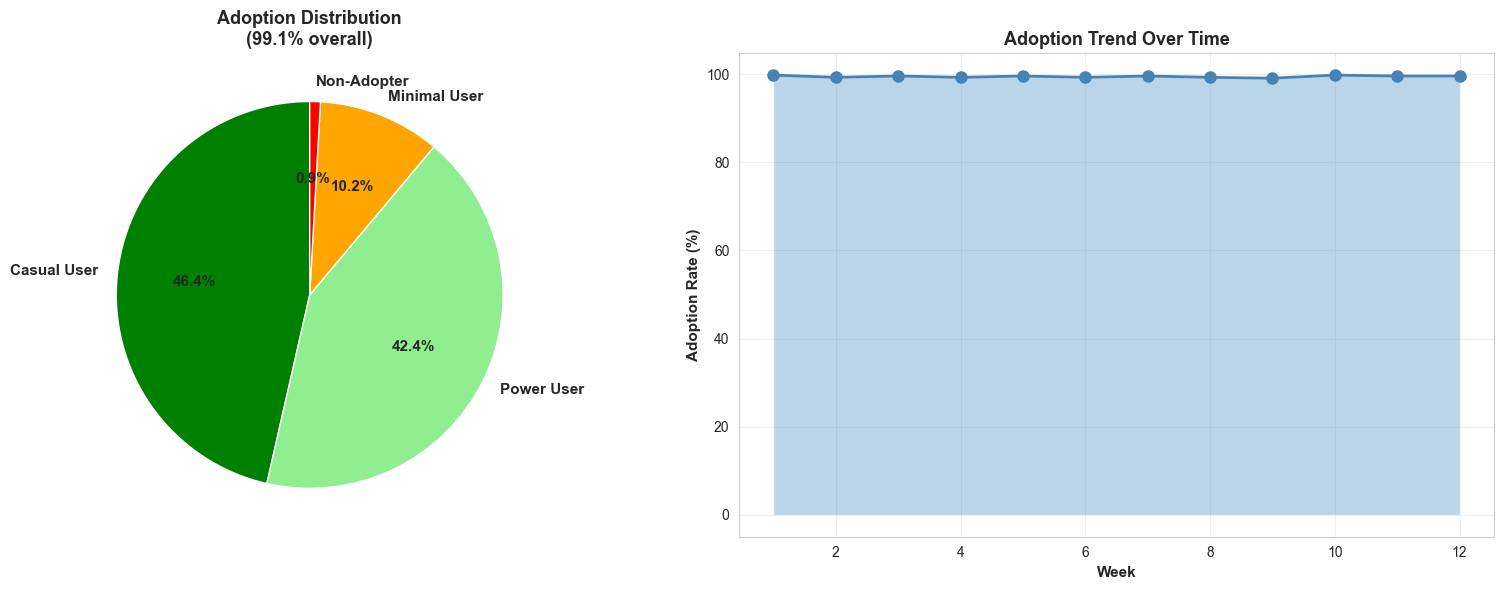

In [2]:
print(f"AI ADOPTION OVERVIEW")
print(f"{'='*80}")

adoption_dist = employees['adoption_level'].value_counts()
for level in ['Power User', 'Casual User', 'Minimal User', 'Non-Adopter']:
    if level in adoption_dist.index:
        count = adoption_dist[level]
        pct = count / len(employees) * 100
        print(f"  {level:15s}: {count:3d} ({pct:5.1f}%)")

overall_adoption = ((len(employees) - adoption_dist.get('Non-Adopter', 0)) / len(employees) * 100)
print(f"\nOverall adoption rate: {overall_adoption:.1f}%")

if overall_adoption >= 80:
    assessment = "EXCELLENT - Critical mass achieved"
elif overall_adoption >= 60:
    assessment = "GOOD - Majority adopting"
elif overall_adoption >= 40:
    assessment = "MODERATE - Needs acceleration"
else:
    assessment = "⚠ LOW - Urgent intervention needed"
    
print(f"Assessment: {assessment}")

# Visualize
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

colors = ['green', 'lightgreen', 'orange', 'red']
ax1.pie(adoption_dist.values, labels=adoption_dist.index, autopct='%1.1f%%',
        colors=colors[:len(adoption_dist)], startangle=90,
        textprops={'fontsize': 11, 'fontweight': 'bold'})
ax1.set_title(f'Adoption Distribution\n({overall_adoption:.1f}% overall)', 
              fontsize=13, fontweight='bold')

ax2.plot(trends['week_number'], trends['adoption_rate_pct'], 
         marker='o', linewidth=2, markersize=8, color='steelblue')
ax2.fill_between(trends['week_number'], trends['adoption_rate_pct'], alpha=0.3)
ax2.set_xlabel('Week', fontsize=11, fontweight='bold')
ax2.set_ylabel('Adoption Rate (%)', fontsize=11, fontweight='bold')
ax2.set_title('Adoption Trend Over Time', fontsize=13, fontweight='bold')
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 2. Adoption by Department and Level


ADOPTION BY SEGMENT

By Department:
  ✓ Customer Success    : 100.0%
  ✓ Finance             : 100.0%
  ✓ HR                  : 100.0%
  ✓ Marketing           : 100.0%
  ✓ Product             :  98.5%
  ✓ Sales               :  98.4%
  ✓ Operations          :  98.2%
  ✓ Engineering         :  97.8%

By Level:
  Director       : 100.0%
  IC1            : 100.0%
  IC2            : 100.0%
  IC3            : 100.0%
  Senior Manager : 100.0%
  Manager        :  98.4%
  IC5            :  98.2%


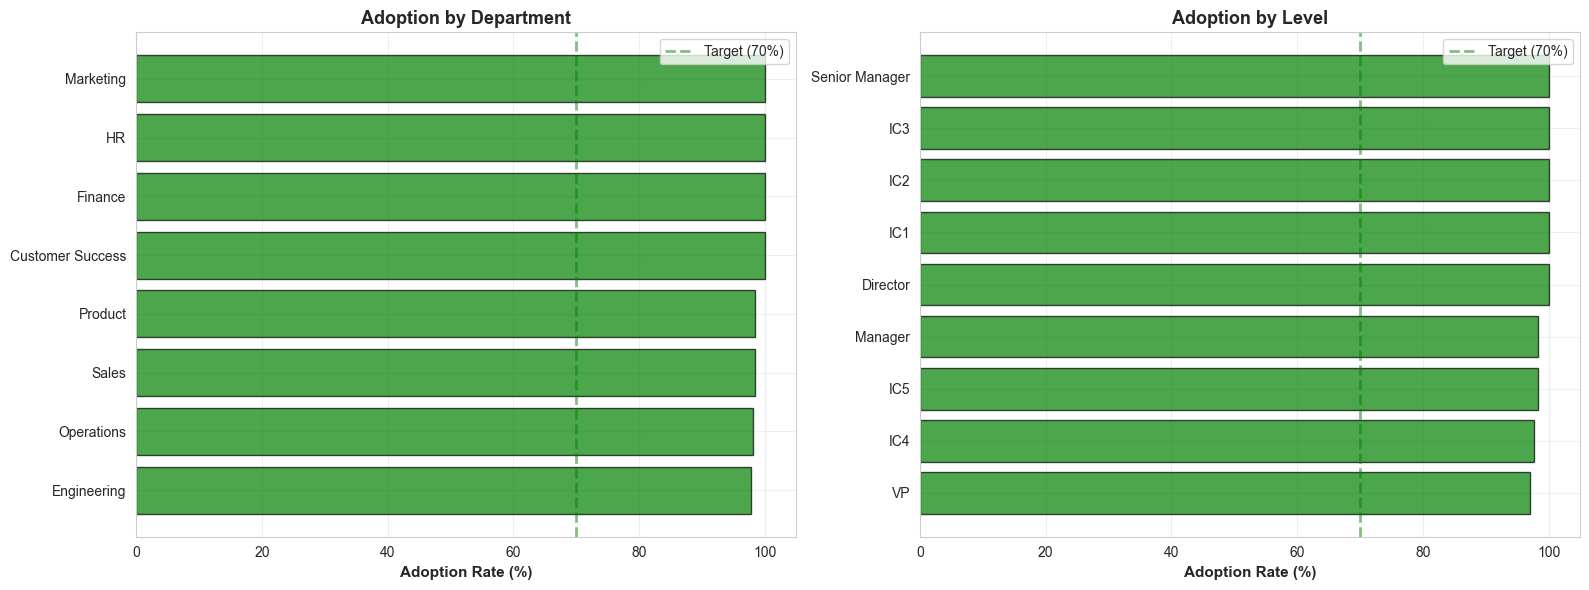

In [3]:
print(f"\nADOPTION BY SEGMENT")
print(f"{'='*80}")

# By department
dept_adoption = employees.groupby('department').apply(
    lambda x: (x['adoption_level'] != 'Non-Adopter').sum() / len(x) * 100
).sort_values(ascending=False)

print(f"\nBy Department:")
for dept, rate in dept_adoption.items():
    marker = "✓" if rate > 70 else "⚠" if rate < 50 else " "
    print(f"  {marker} {dept:20s}: {rate:5.1f}%")

# By level
level_adoption = employees.groupby('level').apply(
    lambda x: (x['adoption_level'] != 'Non-Adopter').sum() / len(x) * 100
).sort_values(ascending=False)

print(f"\nBy Level:")
for level, rate in level_adoption.head(7).items():
    print(f"  {level:15s}: {rate:5.1f}%")

# Visualize
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

dept_sorted = dept_adoption.sort_values()
colors_dept = ['red' if x < 50 else 'orange' if x < 70 else 'green' for x in dept_sorted]
ax1.barh(dept_sorted.index, dept_sorted.values, color=colors_dept, alpha=0.7, edgecolor='black')
ax1.axvline(x=70, color='green', linestyle='--', linewidth=2, alpha=0.5, label='Target (70%)')
ax1.set_xlabel('Adoption Rate (%)', fontsize=11, fontweight='bold')
ax1.set_title('Adoption by Department', fontsize=13, fontweight='bold')
ax1.legend()
ax1.grid(alpha=0.3)

level_sorted = level_adoption.sort_values()
colors_level = ['red' if x < 50 else 'orange' if x < 70 else 'green' for x in level_sorted]
ax2.barh(level_sorted.index, level_sorted.values, color=colors_level, alpha=0.7, edgecolor='black')
ax2.axvline(x=70, color='green', linestyle='--', linewidth=2, alpha=0.5, label='Target (70%)')
ax2.set_xlabel('Adoption Rate (%)', fontsize=11, fontweight='bold')
ax2.set_title('Adoption by Level', fontsize=13, fontweight='bold')
ax2.legend()
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 3. Adoption Predictors

In [4]:
print(f"\nADOPTION PREDICTORS")
print(f"{'='*80}")

# Convert adoption to binary for analysis
employees['is_adopter'] = (employees['adoption_level'] != 'Non-Adopter').astype(int)

# Analyze key factors
adopters = employees[employees['is_adopter'] == 1]
non_adopters = employees[employees['is_adopter'] == 0]

print(f"\nAdopters vs Non-Adopters:")
print(f"  Tech comfort:     {adopters['tech_comfort_score'].mean():.1f} vs {non_adopters['tech_comfort_score'].mean():.1f}")
print(f"  Manager support:  {adopters['manager_ai_support'].mean():.2f} vs {non_adopters['manager_ai_support'].mean():.2f}")
print(f"  Training completion: {adopters['completed_ai_training'].mean()*100:.0f}% vs {non_adopters['completed_ai_training'].mean()*100:.0f}%")

print(f"\nKey findings:")
print(f"  • Tech comfort is {adopters['tech_comfort_score'].mean() / non_adopters['tech_comfort_score'].mean():.1f}x higher for adopters")
print(f"  • Manager support is critical - {adopters['manager_ai_support'].mean():.0%} vs {non_adopters['manager_ai_support'].mean():.0%}")
print(f"  • Training completion correlates strongly with adoption")


ADOPTION PREDICTORS

Adopters vs Non-Adopters:
  Tech comfort:     3.0 vs 1.9
  Manager support:  0.72 vs 0.54
  Training completion: 65% vs 0%

Key findings:
  • Tech comfort is 1.6x higher for adopters
  • Manager support is critical - 72% vs 54%
  • Training completion correlates strongly with adoption


## Key Takeaways

1. **Adoption is growing but uneven**: Some teams are ahead, others lag
2. **Manager support drives adoption**: Teams with supportive managers adopt faster
3. **Training matters**: Completing training significantly increases usage
4. **Tech comfort predicts adoption**: But training can bridge the gap

**Recommended Actions**:
- Target low-adoption departments with focused campaigns
- Train managers to model and encourage AI use
- Make training more accessible and required
- Celebrate early adopter success stories